In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def sum_AP(a,n,d):
    sum_ = (n*(a + a + (n-1)*d))/2
    return sum_

In [4]:
a = 1
n = 100
d = 1

In [5]:
AP_sequence = np.arange(a,a+n*d,d)
index = np.arange(1,n+1,1)
print('AP sequence')
print(AP_sequence)

AP sequence
[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100]


In [6]:
sum_result = sum_AP(a,n,d)
sum_result_2 = np.sum(AP_sequence)

In [7]:
sum_result

5050.0

In [8]:
sum_result

5050.0

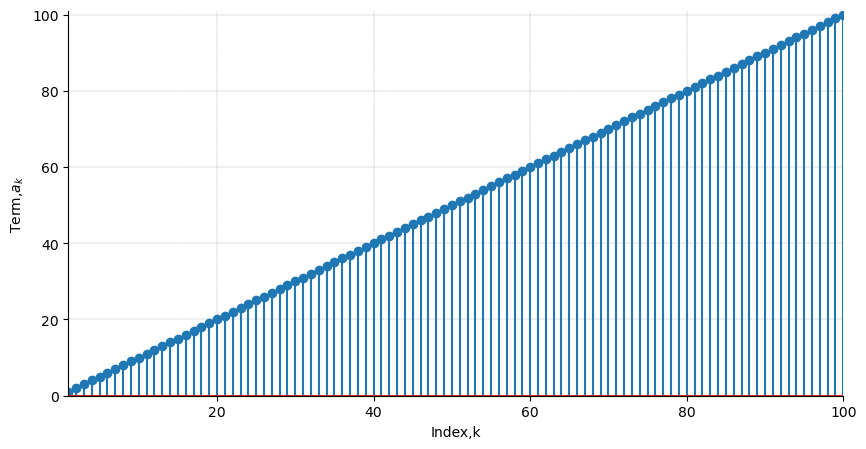

In [14]:
fig,ax = plt.subplots(figsize = (10,5))

plt.xlabel('Index,k')
plt.ylabel('Term,$a_k$')

plt.stem(index,AP_sequence)
ax.grid(ls = '--',lw = 0.25,color = '0.5')
plt.ylim(0,AP_sequence.max() + 1)
plt.xlim(index.min(),index.max())
plt.gca().spines[['right','top']].set_visible(False)

In [15]:
p = plt.rcParams  # 获取默认绘图参数
#p["font.sans-serif"] = ["Roboto"]  # 设置无衬线字体为 Roboto
p["font.weight"] = "light"  # 设置字体粗细为 light
p["ytick.minor.visible"] = True  # 显示 y 轴的小刻度
p["xtick.minor.visible"] = True  # 显示 x 轴的小刻度
p["axes.grid"] = True  # 启用坐标轴网格
p["grid.color"] = "0.5"  # 设置网格颜色为灰色
p["grid.linewidth"] = 0.5  # 设置网格线宽度

In [16]:
a = 1
n = 50
q_list = [1.1,1,0.9,-0.9,-1,-1.1]

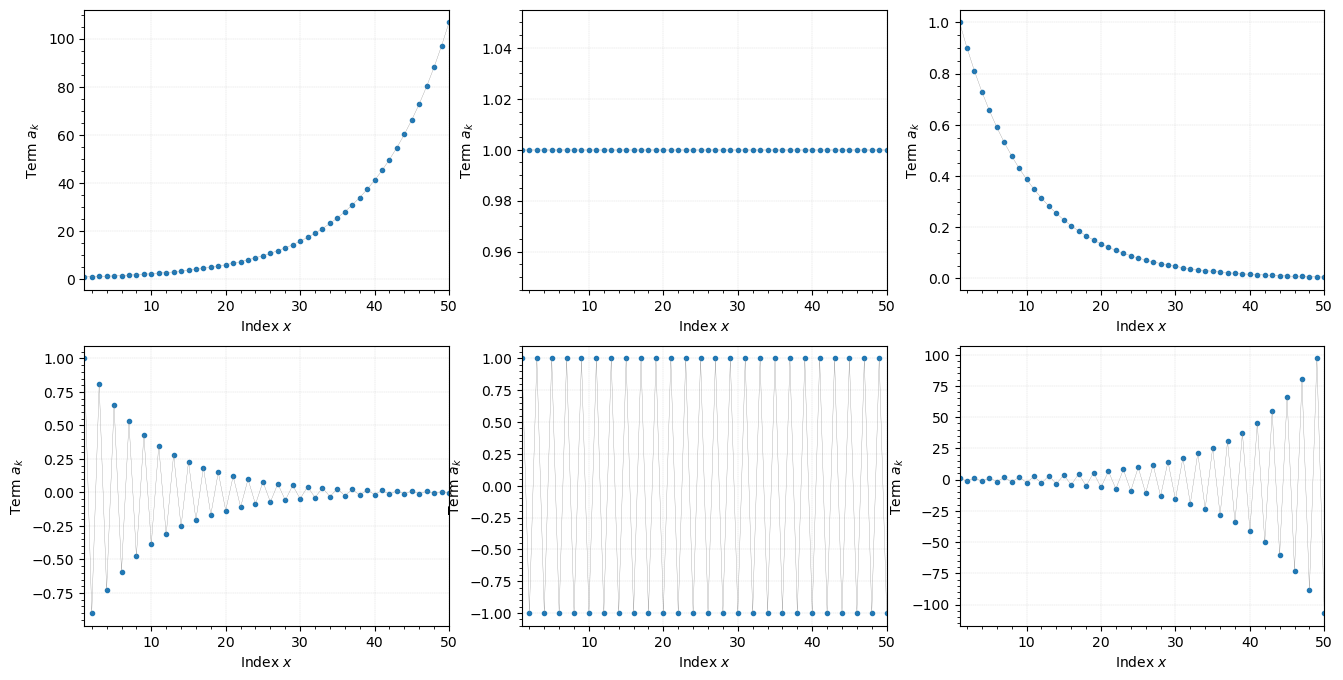

In [20]:
fig = plt.figure(figsize = (16,8))

for pos,q in enumerate(q_list):
    GP_sequence = [a*q**i for i in range(n)]
    index = np.arange(1,n+1,1)

    ax = fig.add_subplot(2,3,pos+1)
    ax.set_xlabel('Index $x$')
    ax.set_ylabel('Term $a_k$')
    ax.set_xlim(1,n)
    ax.plot(index,GP_sequence,marker = '.',markersize = 6,linestyle = 'None')
    ax.plot(index,GP_sequence,color = '0.5',lw = 0.2)
    ax.grid(linestyle = '--',lw = 0.25,color = '0.8')

In [21]:
def fib(n):
    if n<=1:
        return n
    else:
        return (fib(n-1) + fib(n - 2))

In [22]:
n = 10
for i in range(n):
    print(fib(i))

0
1
1
2
3
5
8
13
21
34


In [23]:
a = 13+8
a/13

1.6153846153846154

In [25]:
b = 8+5
b/8

1.625

In [26]:
21/13

1.6153846153846154

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
def heatmap_sum(data,i_array,j_array,title):
    fig,ax = plt.subplots(figsize = (10,10))
    ax = sns.heatmap(data,cmap = 'RdYlBu_r',
                    cbar_kws = {'orientation':'horizontal'},
                    yticklabels = i_array,xticklabels = j_array,
                    ax = ax)
    ax.set_xlabel('Index, $j$')
    ax.set_ylabel('Index, $i$')

    ax.set_aspect('equal')
    plt.title(title)
    plt.yticks(rotation = 0)
    ax.grid(False)
    ax.minorticks_off()

In [41]:
np.random.seed(0)

m = 12
n = 8

j_array = np.arange(1,m+1)
i_array = np.arange(1,n+1)
jj,ii = np.meshgrid(j_array,i_array)

#均值,标准差,形状
a_ij = np.random.normal(loc = 0.0,scale = 1.0,size = (n,m))#

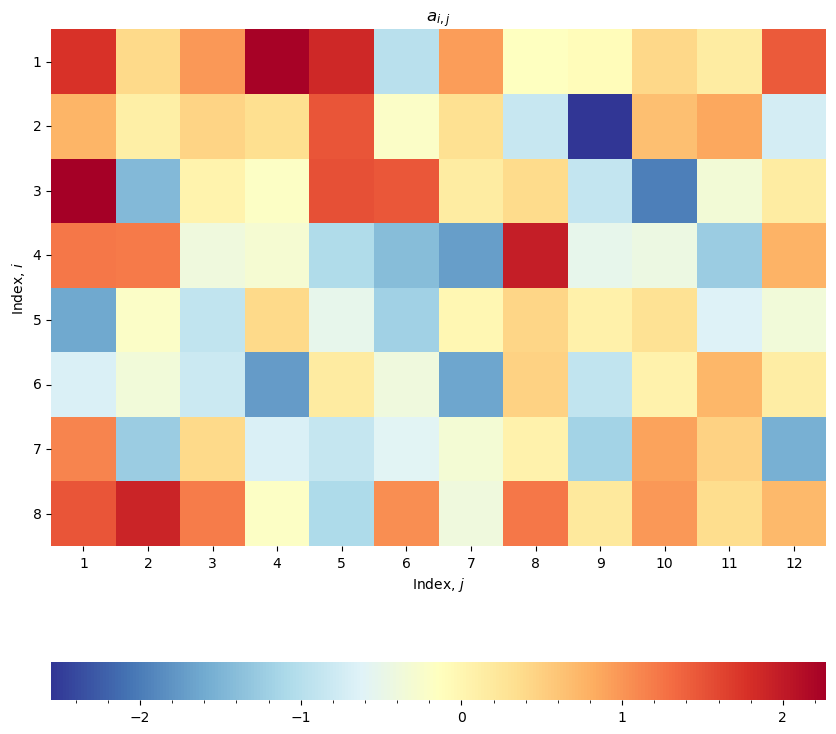

In [42]:
title = '$a_{i,j}$'
heatmap_sum(a_ij,i_array,j_array,title)

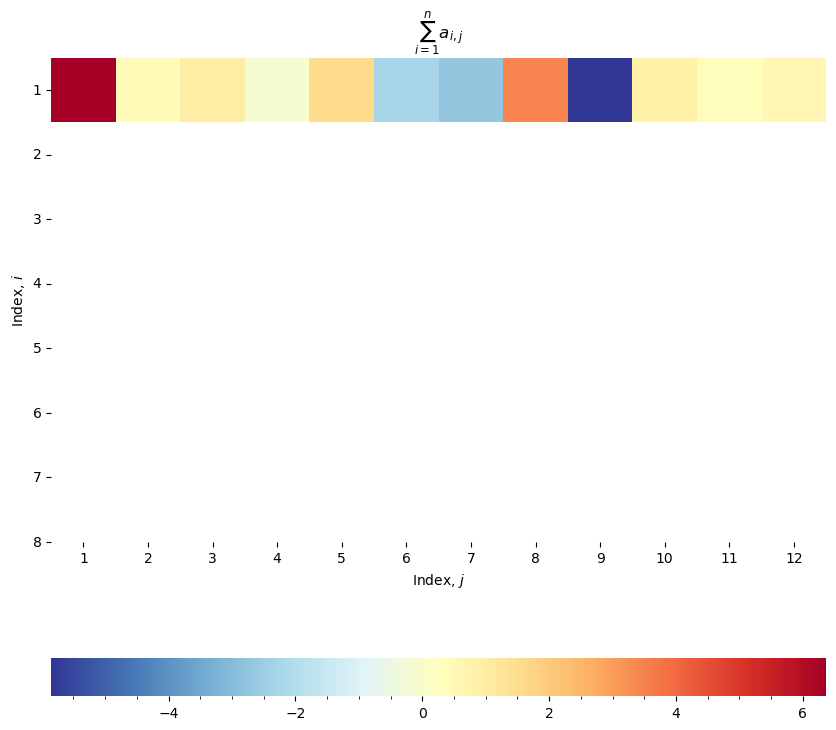

In [50]:
all_1 = np.ones((8,1))
sum_over_i = all_1.T @ a_ij

title = r'$\sum_{i = 1}^{n} a_{i,j}$'
#相对的index扩大是扩大了绘图区域,不是数据本身的lim(lim只能是矩阵中的格子上的元素)
heatmap_sum(sum_over_i,i_array,j_array,title)

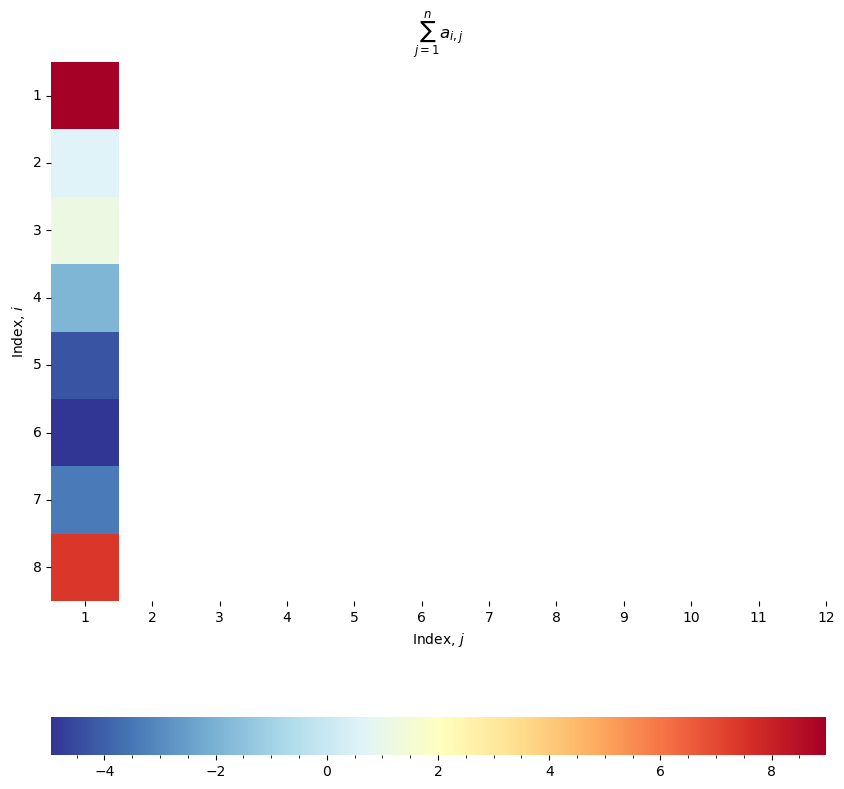

In [51]:
all_1 = np.ones((12,1))
sum_over_i = a_ij @ all_1

title = r'$\sum_{j = 1}^{n} a_{i,j}$'
heatmap_sum(sum_over_i,i_array,j_array,title)

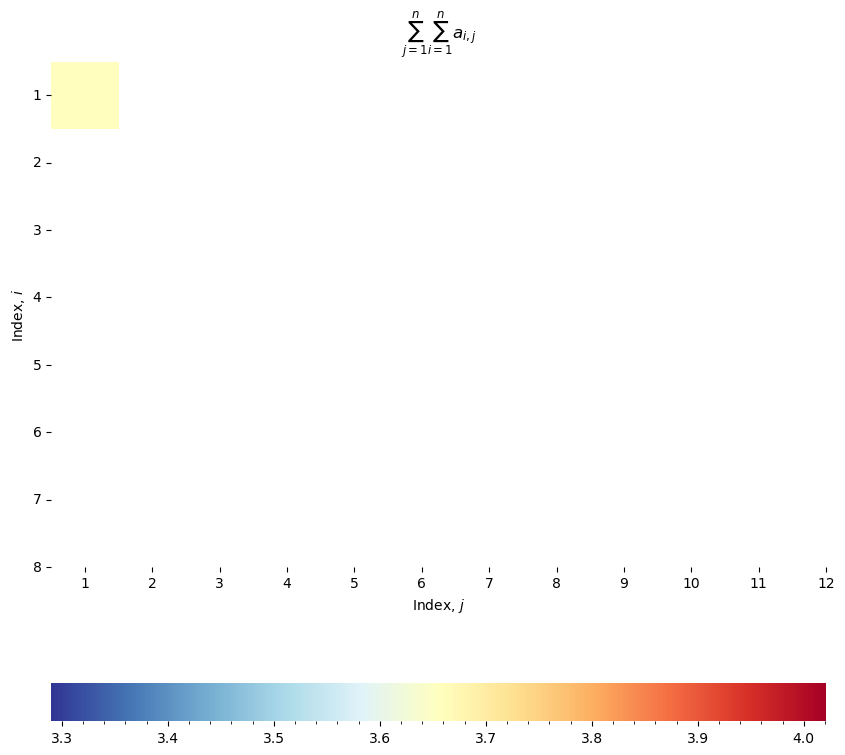

In [52]:
all_1_1 = np.ones((8,1))
all_1_2 = np.ones((12,1))
sum_over_i = all_1_1.T @ a_ij @ all_1

title = r'$\sum_{j = 1}^{n} \sum_{i = 1}^{n} a_{i,j}$'
heatmap_sum(sum_over_i,i_array,j_array,title)

In [87]:
from sympy import limit_seq,Sum,lambdify,factorial #极限,求和,符号化函数,阶乘函数
from sympy.abc import n,k
import numpy as np
import matplotlib.pyplot as plt

In [77]:
#Sum第一个参数是数学表达式,第二个参数中(k为求和变量,0为下限n为上限) 理解为公式
#Sum是求和符号的表达式,需要调用pyhton函数才能创建
#创建了一个公式,依赖了n的部分表达
seq_sum = Sum(1 / 2**k,(k,0,n))
seq_sum = Sum(1 / ((k+1)*(k+2)),(k,0,n))
seq_sum = Sum(1 / factorial(k),(k,0,n))

In [78]:
#参数中一个是要求极限的表达式,第二个是指标变量 默认n为正无穷
#求极限时候知道了要将n设置为极限,这一步是多写了一个求极限的符号,并且算出来了
seq_limit = limit_seq(seq_sum,n)

In [79]:
seq_sum_fcn = lambdify(n,seq_sum)

In [80]:
#求浮点数值的方法,写在了类中
#subs表示替换,将n替换为5
#得到的结果是在sympy语境之下的浮点数
seq_sum.evalf(subs = {n:5})

2.71666666666667

In [81]:
n_array = np.arange(0,100+1,1)

In [82]:
seq_sum_array = []

for n in n_array:
    seq_n = seq_sum_fcn(n)
    seq_sum_array.append(seq_n)

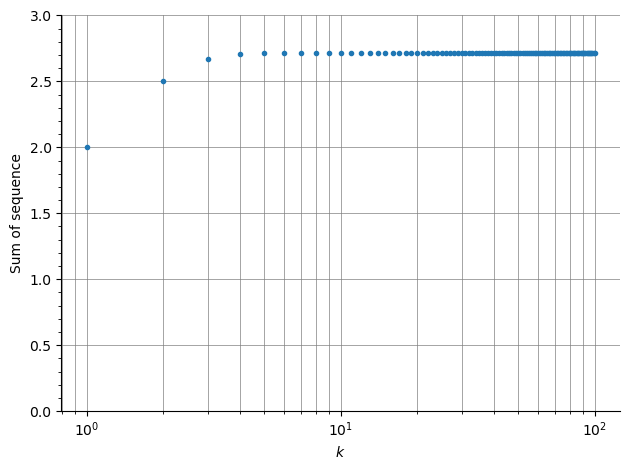

In [83]:
fig,ax = plt.subplots()

ax.plot(n_array,seq_sum_array,linestyle = 'None',marker = '.')

ax.set_xlabel('$k$')
ax.set_ylabel('Sum of sequence')
ax.set_xscale('log')
ax.set_ylim(0, 3)
ax.spines[['right','top']].set_visible(False)
plt.grid(True, which="both", axis='x')#在x轴显示大小两种刻度的连线
plt.tight_layout()

1.96875000000000


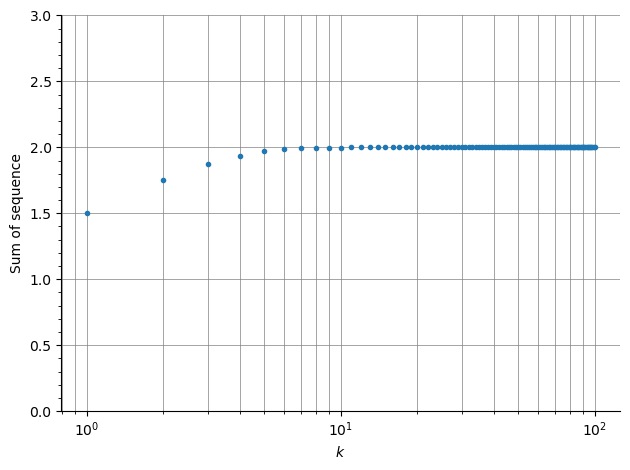

In [85]:
seq_sum = Sum(1 / 2**k,(k,0,n))
seq_limit = limit_seq(seq_sum,n)
seq_sum_fcn = lambdify(n,seq_sum)
print(seq_sum.evalf(subs = {n:5}))#只显示数据的给人看的形式 调用了__str__() 调用对象自己的字符串表示
n_array = np.arange(0,100+1,1)

seq_sum_array = []

for n in n_array:
    seq_n = seq_sum_fcn(n)
    seq_sum_array.append(seq_n)

fig,ax = plt.subplots()

ax.plot(n_array,seq_sum_array,linestyle = 'None',marker = '.')

ax.set_xlabel('$k$')
ax.set_ylabel('Sum of sequence')
ax.set_xscale('log')
ax.set_ylim(0, 3)
ax.spines[['right','top']].set_visible(False)
plt.grid(True, which="both", axis='x')#在x轴显示大小两种刻度的连线
plt.tight_layout()

0.500000000000000


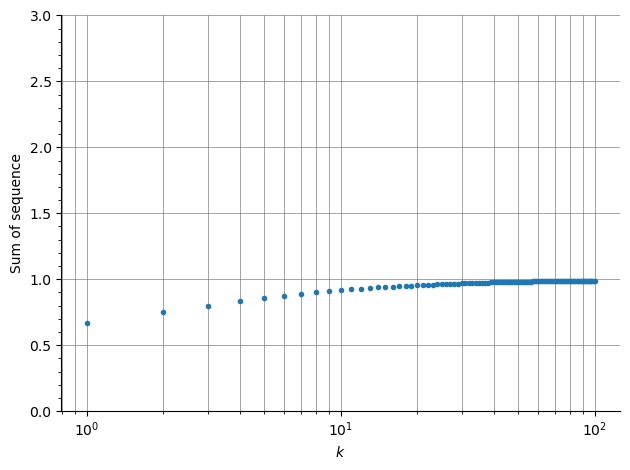

In [88]:
seq_sum = Sum(1 / ((k+1)*(k+2)),(k,0,n))
seq_limit = limit_seq(seq_sum,n)
seq_sum_fcn = lambdify(n,seq_sum)
print(seq_sum.evalf(subs = {n:0}))#这种求值方法和生成数值函数方法互不干预
n_array = np.arange(0,100+1,1)

seq_sum_array = []

for a in n_array:
    seq_n = seq_sum_fcn(a)
    seq_sum_array.append(seq_n)

fig,ax = plt.subplots()

ax.plot(n_array,seq_sum_array,linestyle = 'None',marker = '.')

ax.set_xlabel('$k$')
ax.set_ylabel('Sum of sequence')
#坐标系为log
#当x轴为0(实际长度进行了运算) 代表(实际数值是1进行的log_10的运算)log_10(1) = 0 这时候代表n = 1
ax.set_xscale('log')
ax.set_ylim(0, 3)
ax.spines[['right','top']].set_visible(False)
plt.grid(True, which="both", axis='x')#在x轴显示大小两种刻度的连线
plt.tight_layout()

In [89]:
n_array = np.arange(1,100+1,1)

In [90]:
a_n_array = (-1)**(n_array + 1)/(2*n_array - 1)
a_n_array

array([ 1.        , -0.33333333,  0.2       , -0.14285714,  0.11111111,
       -0.09090909,  0.07692308, -0.06666667,  0.05882353, -0.05263158,
        0.04761905, -0.04347826,  0.04      , -0.03703704,  0.03448276,
       -0.03225806,  0.03030303, -0.02857143,  0.02702703, -0.02564103,
        0.02439024, -0.02325581,  0.02222222, -0.0212766 ,  0.02040816,
       -0.01960784,  0.01886792, -0.01818182,  0.01754386, -0.01694915,
        0.01639344, -0.01587302,  0.01538462, -0.01492537,  0.01449275,
       -0.01408451,  0.01369863, -0.01333333,  0.01298701, -0.01265823,
        0.01234568, -0.01204819,  0.01176471, -0.01149425,  0.01123596,
       -0.01098901,  0.01075269, -0.01052632,  0.01030928, -0.01010101,
        0.00990099, -0.00970874,  0.00952381, -0.00934579,  0.00917431,
       -0.00900901,  0.00884956, -0.00869565,  0.00854701, -0.00840336,
        0.00826446, -0.00813008,  0.008     , -0.00787402,  0.00775194,
       -0.00763359,  0.0075188 , -0.00740741,  0.00729927, -0.00

In [91]:
a_n_cumsum = np.cumsum(a_n_array)#累计求和
a_n_cumsum

array([1.        , 0.66666667, 0.86666667, 0.72380952, 0.83492063,
       0.74401154, 0.82093462, 0.75426795, 0.81309148, 0.7604599 ,
       0.80807895, 0.76460069, 0.80460069, 0.76756365, 0.80204641,
       0.76978835, 0.80009138, 0.77151995, 0.79854698, 0.77290595,
       0.7972962 , 0.77404038, 0.7962626 , 0.77498601, 0.79539417,
       0.77578633, 0.79465425, 0.77647243, 0.79401629, 0.77706714,
       0.79346058, 0.77758757, 0.79297218, 0.77804681, 0.79253956,
       0.77845506, 0.79215369, 0.77882035, 0.79180737, 0.77914914,
       0.79149482, 0.77944663, 0.79121133, 0.77971708, 0.79095303,
       0.77996402, 0.79071671, 0.78019039, 0.79049967, 0.78039866,
       0.79029965, 0.78059092, 0.79011472, 0.78076893, 0.78994324,
       0.78093423, 0.78978379, 0.78108814, 0.78963515, 0.78123179,
       0.78949625, 0.78136617, 0.78936617, 0.78149215, 0.78924409,
       0.7816105 , 0.7891293 , 0.78172189, 0.78902116, 0.78182692,
       0.78891912, 0.78192611, 0.78882266, 0.78201994, 0.78873

In [92]:
#得到π的近似
pi_appx = 4*a_n_cumsum

<StemContainer object of 3 artists>

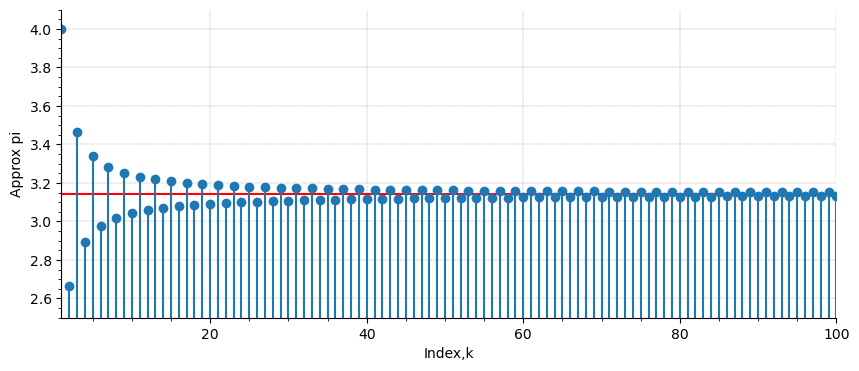

In [99]:
fig,ax = plt.subplots(figsize = (10,4))

plt.xlabel('Index,k')
plt.ylabel('Approx pi')

ax.grid(linestyle = '--',linewidth = 0.25,color = '0.5')
plt.axhline(y = np.pi,color = 'r',linestyle = '-')

plt.xlim(n_array.min(),n_array.max())
plt.ylim(2.5,4.1)
ax.spines[['right','top']].set_visible(False)

ax.stem(n_array,pi_appx)